In [5]:
# ===== 1) Utility: random crop di waveform =====
def random_crop_wave(y, sr, win_sec=3.0):
    win = int(win_sec * sr)
    if len(y) <= win:
        pad = win - len(y)
        y = np.pad(y, (0, pad), mode="constant")
        return y, 0
    start = np.random.randint(0, len(y) - win + 1)
    return y[start:start+win], start

def center_crop_wave(y, sr, win_sec=3.0):
    win = int(win_sec * sr)
    if len(y) <= win:
        pad = win - len(y)
        y = np.pad(y, (0, pad), mode="constant")
        return y, 0
    start = (len(y) - win) // 2
    return y[start:start+win], start

def mel3_from_wave(y, sr):
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0
    )
    logS = librosa.power_to_db(S, ref=np.max).astype(np.float32)
    d1   = librosa.feature.delta(logS)
    d2   = librosa.feature.delta(logS, order=2)
    return np.stack([logS, d1, d2], axis=-1).astype(np.float32)  # (H,T,3)

def norm_then_pad(x, max_len):
    H, W, C = x.shape
    x = x.copy()
    for c in range(C):
        mu, sd = x[:, :W, c].mean(), x[:, :W, c].std() + 1e-6
        x[:, :W, c] = (x[:, :W, c] - mu) / sd
    if W >= max_len:
        return x[:, :max_len, :]
    out = np.zeros((H, max_len, C), dtype=np.float32)
    out[:, :W, :] = x
    return out

# ===== 2) Build dataset dengan random crop & balancing =====
WIN_SEC = 3.0             # panjang cuplikan
AUG_PER_FILE_BASE = 2     # target jumlah crop minimum per file
BALANCE_TO = 60           # target total sample per kelas (naikkan jika ingin)

def build_balanced_dataset(data_dir, subdir=""):
    root = Path(data_dir)
    if subdir:
        class_names = [subdir]
        class_dirs  = [root/subdir]
    else:
        class_names = sorted([d.name for d in root.iterdir() if d.is_dir()])
        class_dirs  = [root/n for n in class_names]

    X_list, y_list, paths = [], [], []
    counts = []

    # hitung jumlah file per kelas dulu
    for d in class_dirs:
        files = list_audio_files(d)
        counts.append(len(files))

    for ci, (cname, cdir, n_files) in enumerate(zip(class_names, class_dirs, counts)):
        files = list_audio_files(cdir)
        target = max(BALANCE_TO, n_files * AUG_PER_FILE_BASE)  # target per kelas
        rep = max(1, (target + n_files - 1) // n_files)        # berapa crop per file

        print(f"[{cname}] {n_files} file → {rep} crop/file (target ≈ {target})")

        for f in files:
            try:
                y_wav, sr = load_audio(str(f), sr=SR, duration=None)  # pakai full durasi
                if np.max(np.abs(y_wav)) > 0:
                    y_wav = y_wav / np.max(np.abs(y_wav))
                # buat beberapa crop random per file
                for _ in range(rep):
                    seg, _ = random_crop_wave(y_wav, sr, win_sec=WIN_SEC)
                    x = mel3_from_wave(seg, sr)
                    X_list.append(x); y_list.append(ci); paths.append(str(f))
            except Exception as e:
                print("Gagal:", f, e)

    return X_list, np.array(y_list, np.int64), class_names, np.array(paths)

# Bangun dataset baru
X_list, y, class_names, paths = build_balanced_dataset(DATA_DIR, SUBDIR)

# hitung panjang dan pad
widths = np.array([x.shape[1] for x in X_list])
max_len = int(np.percentile(widths, 95))
max_len = max(64, max_len)           # jaga minimal lebar
X_pad = np.stack([norm_then_pad(x, max_len) for x in X_list], axis=0)
print("Balanced X_pad:", X_pad.shape, "classes:", class_names)

# Split stratified
X_train, X_val, y_train, y_val = train_test_split(
    X_pad, y, test_size=0.2, stratify=y, random_state=SEED
)

# Class weights (boleh kecil efeknya sekarang dataset sudah dibalance)
from sklearn.utils.class_weight import compute_class_weight
num_classes = len(class_names)
cls_w = compute_class_weight('balanced', classes=np.arange(num_classes), y=y_train)
class_weights = {i: float(w) for i, w in enumerate(cls_w)}
print("class_weights:", class_weights)

# ===== 3) Model & compile (tanpa focal loss; cukup CE + class_weight) =====
USE_FOCAL = False
opt = optimizers.Adam(learning_rate=3e-4)  # lebih rendah → stabil
loss_fn = "sparse_categorical_crossentropy"

# SpecAugment sedikit lebih kuat
def build_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x = SpecAugment(time_mask=0.12, freq_mask=0.12)(inp)
    def block(x, f, drop):
        x = layers.Conv2D(f, 3, padding="same", kernel_regularizer=regularizers.l2(2e-4))(x)
        x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
        x = layers.Conv2D(f, 3, padding="same", kernel_regularizer=regularizers.l2(2e-4))(x)
        x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D((2,2))(x); x = layers.Dropout(drop)(x)
        return x
    x = block(x, 32, 0.30)
    x = block(x, 64, 0.35)
    x = block(x, 128,0.40)
    x = block(x, 192,0.45)
    x = layers.Conv2D(256, 3, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(2e-4))(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out)

model = build_cnn((N_MELS, max_len, X_pad.shape[-1]), num_classes)
model.compile(optimizer=opt, loss=loss_fn, metrics=["accuracy"])

cbs = [
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint("best_cnn_balanced.keras", monitor="val_loss", save_best_only=True, verbose=1),
]

hist = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    class_weight=class_weights,
    callbacks=cbs,
    verbose=1
)

# ===== 4) (Opsional) TTA sederhana untuk validasi =====
def predict_tta_center_shift(model, X, shifts=(0, 8, -8)):
    # roll di sumbu waktu (W) dan rata-ratakan prediksi
    probs = []
    for s in shifts:
        Xs = tf.roll(X, shift=s, axis=2).numpy()
        probs.append(model.predict(Xs, verbose=0))
    return np.mean(probs, axis=0)

y_val_prob = predict_tta_center_shift(model, X_val)
y_val_pred = np.argmax(y_val_prob, axis=1)
print("Val acc:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, target_names=class_names, digits=4))
print("Confusion:\n", confusion_matrix(y_val, y_val_pred))


[audioanjing] 37 file → 2 crop/file (target ≈ 74)
[audiobabi] 24 file → 3 crop/file (target ≈ 60)
[audiobajingan] 41 file → 2 crop/file (target ≈ 82)
Balanced X_pad: (228, 128, 130, 3) classes: ['audioanjing', 'audiobabi', 'audiobajingan']
class_weights: {0: 1.0282485875706215, 1: 1.0459770114942528, 2: 0.9333333333333333}
Epoch 1/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - accuracy: 0.2993 - loss: 1.3542
Epoch 1: val_loss improved from None to 1.29033, saving model to best_cnn_balanced.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.3462 - loss: 1.3320 - val_accuracy: 0.3261 - val_loss: 1.2903 - learning_rate: 3.0000e-04
Epoch 2/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 787ms/step - accuracy: 0.3748 - loss: 1.2923
Epoch 2: val_loss did not improve from 1.29033
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 852ms/step - accuracy: 0.3846 - loss: 1.3058 - val_accuracy: 0.3043 - val_loss: 1.3000 - learning_rate: 3.0000e-04
Epoch 3/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 826ms/step - accuracy: 0.4574 - loss: 1.2245
Epo

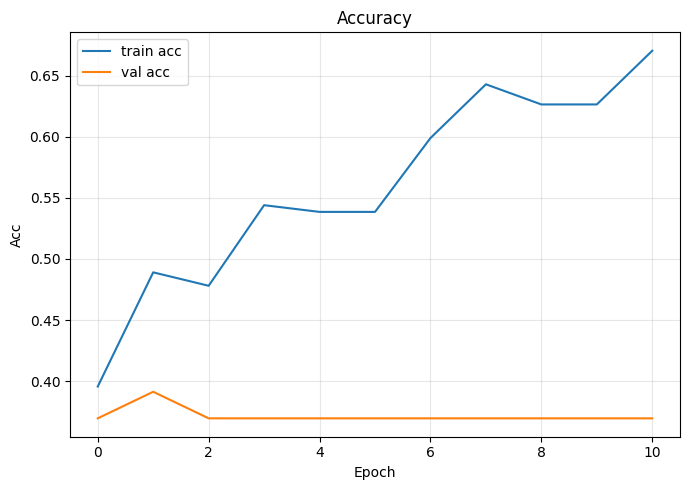

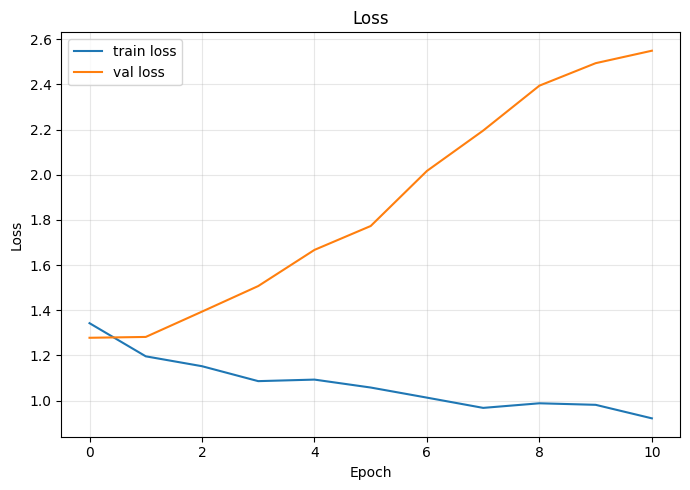

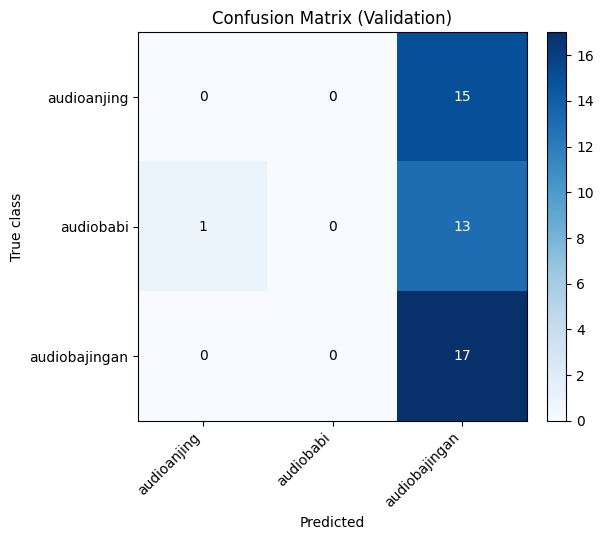

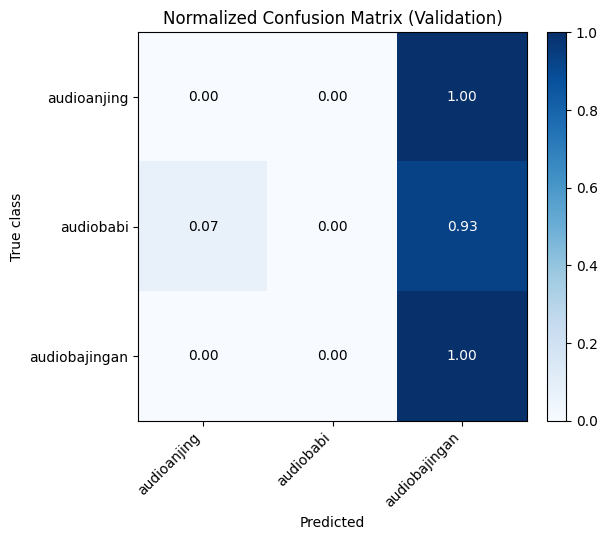

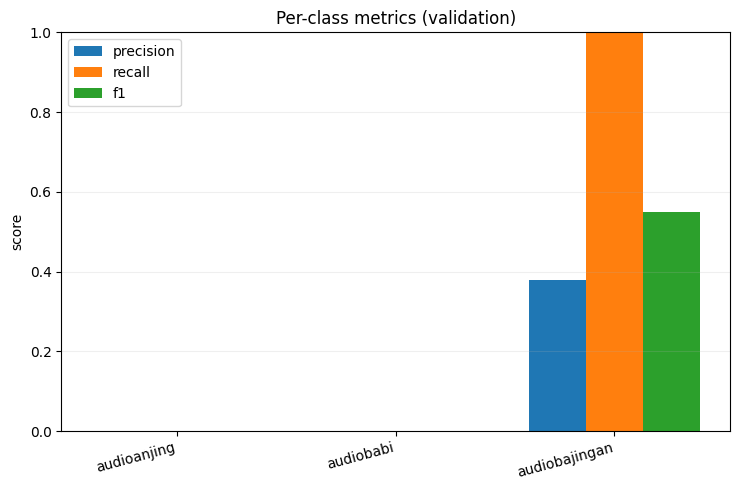

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# ---------- 1) Learning curves ----------
def plot_history(h):
    # Accuracy
    plt.figure(figsize=(7,5))
    plt.plot(h.history['accuracy'], label='train acc')
    plt.plot(h.history['val_accuracy'], label='val acc')
    plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Acc')
    plt.grid(True, alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

    # Loss
    plt.figure(figsize=(7,5))
    plt.plot(h.history['loss'], label='train loss')
    plt.plot(h.history['val_loss'], label='val loss')
    plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.grid(True, alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

plot_history(hist)

# ---------- 2) Prediksi & Confusion Matrix ----------
# Jika kamu sudah punya y_val_prob (mis. dari TTA), pakai itu.
try:
    y_prob = y_val_prob
except NameError:
    y_prob = model.predict(X_val, verbose=0)

y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_val, y_pred, labels=np.arange(len(class_names)))

def plot_cm(cm, class_names, normalize=False, title="Confusion Matrix"):
    if normalize:
        cm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
        fmt = ".2f"; cmap = plt.cm.Blues
    else:
        fmt = "d";   cmap = plt.cm.Blues

    plt.figure(figsize=(6.5,5.5))
    plt.imshow(cm, interpolation="nearest", cmap=cmap)
    plt.title(title); plt.colorbar(fraction=0.046, pad=0.04)
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True class"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()

plot_cm(cm, class_names, normalize=False, title="Confusion Matrix (Validation)")
plot_cm(cm, class_names, normalize=True,  title="Normalized Confusion Matrix (Validation)")

# ---------- 3) Precision/Recall/F1 bar chart ----------
report = classification_report(y_val, y_pred, target_names=class_names, output_dict=True)
prec = [report[c]['precision'] for c in class_names]
rec  = [report[c]['recall']    for c in class_names]
f1   = [report[c]['f1-score']  for c in class_names]

x = np.arange(len(class_names)); w = 0.26
plt.figure(figsize=(7.5,5))
plt.bar(x - w, prec, width=w, label='precision')
plt.bar(x,      rec,  width=w, label='recall')
plt.bar(x + w,  f1,   width=w, label='f1')
plt.xticks(x, class_names, rotation=15, ha='right')
plt.ylim(0,1); plt.ylabel('score'); plt.title('Per-class metrics (validation)')
plt.grid(True, axis='y', alpha=.2); plt.legend()
plt.tight_layout(); plt.show()


In [7]:
# ---------- 1) Build dataset (keep your X_list, y from earlier) ----------
# (If you’re using the balanced random-crop builder, keep that;
# this patch focuses on normalization & training stability.)

# Compute TRAIN statistics (mean/std) *per mel bin & per channel* using only train set
from sklearn.model_selection import train_test_split
widths = np.array([x.shape[1] for x in X_list])
max_len = int(np.percentile(widths, 95))
max_len = max(64, max_len)

def pad_to(x, max_len):
    H, W, C = x.shape
    if W >= max_len:
        return x[:, :max_len, :]
    out = np.zeros((H, max_len, C), dtype=np.float32)
    out[:, :W, :] = x
    return out

# First pad all, but DO NOT normalize yet
X_pad = np.stack([pad_to(x, max_len) for x in X_list], axis=0).astype(np.float32)

# Split first, then compute normalization stats on TRAIN ONLY
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_pad, y, test_size=0.2, stratify=y, random_state=SEED
)

# Per-mel, per-channel mean/std over TRAIN (aggregate across time & batch)
train_mean = X_train_raw.mean(axis=(0, 2))          # shape (H, C)
train_std  = X_train_raw.std(axis=(0, 2)) + 1e-6    # shape (H, C)

# Apply the SAME normalization to both train and val
def apply_train_norm(X, mean=train_mean, std=train_std):
    # X: (N, H, W, C); we need broadcasting over (H, C)
    return (X - mean[None, :, None, :]) / std[None, :, None, :]

X_train = apply_train_norm(X_train_raw)
X_val   = apply_train_norm(X_val_raw)

print("Shapes:", X_train.shape, X_val.shape)

# ---------- 2) Model (milder SpecAugment or OFF first) ----------
def build_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    # try OFF first to check baseline; put back 0.06/0.06 if baseline is good
    x = inp  # SpecAugment(time_mask=0.06, freq_mask=0.06)(inp)

    def block(x, f, drop):
        x = layers.Conv2D(f, 3, padding="same",
                          kernel_regularizer=regularizers.l2(2e-4))(x)
        x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
        x = layers.Conv2D(f, 3, padding="same",
                          kernel_regularizer=regularizers.l2(2e-4))(x)
        x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D((2,2))(x); x = layers.Dropout(drop)(x)
        return x

    x = block(x, 32,  0.25)
    x = block(x, 64,  0.30)
    x = block(x, 128, 0.35)
    x = block(x, 192, 0.40)

    x = layers.Conv2D(256, 3, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Dropout(0.45)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(2e-4))(x)
    x = layers.Dropout(0.45)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out)

num_classes = int(np.max(y)) + 1
model = build_cnn((X_train.shape[1], X_train.shape[2], X_train.shape[3]), num_classes)
model.summary()

# ---------- 3) Compile: plain CE, no class weights/focal (stability first) ----------
opt = optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

cbs = [
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4,
                                min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor="val_loss", patience=10,
                            restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint("best_cnn_trainstats_norm.keras",
                              monitor="val_loss", save_best_only=True, verbose=1),
]

hist = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=32,
    # class_weight=None  # keep off; add later if needed
    callbacks=cbs,
    verbose=1
)

# Evaluate
y_val_prob = model.predict(X_val, verbose=0)
y_val_pred = np.argmax(y_val_prob, axis=1)
print("Val acc:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, target_names=class_names, digits=4))
print("Confusion:\n", confusion_matrix(y_val, y_val_pred))


Shapes: (182, 128, 130, 3) (46, 128, 130, 3)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 128, 130, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_36 (Conv2D)                   │ (None, 128, 130, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_36               │ (None, 128, 130, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_36 (Activation)           │ (None, 128, 130, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_37 (Conv2D)                   │ (None, 128, 130, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_37               │ (None, 128, 130, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_37 (Activation)           │ (None, 128, 130, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 64, 65, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 64, 65, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_38 (Conv2D)                   │ (None, 64, 65, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_38               │ (None, 64, 65, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_38 (Activation)           │ (None, 64, 65, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_39 (Conv2D)                   │ (None, 64, 65, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_39               │ (None, 64, 65, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_39 (Activation)           │ (None, 64, 65, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_40 (Conv2D)                   │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_40               │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │              

 Total params: 1,353,891 (5.16 MB)

 Trainable params: 1,351,715 (5.16 MB)

 Non-trainable params: 2,176 (8.50 KB)

Epoch 1/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.3895 - loss: 1.3372
Epoch 1: val_loss improved from None to 1.27835, saving model to best_cnn_trainstats_norm.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 975ms/step - accuracy: 0.3956 - loss: 1.3430 - val_accuracy: 0.3696 - val_loss: 1.2783 - learning_rate: 0.0010
Epoch 2/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.4578 - loss: 1.2365
Epoch 2: val_loss did not improve from 1.27835
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 831ms/step - accuracy: 0.4890 - loss: 1.1963 - val_accuracy: 0.3913 - val_loss: 1.2821 - learning_rate: 0.0010
Epoch 3/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.4720 - loss: 1.1612
Epoch 3: val_loss did not improve from 1.27835
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 829ms/step - accuracy: 0.4780 - loss: 1.1525 - val_accuracy: 0.3696 - val_loss: 1.3942 - learning_rate: 0.0010
Epoch 4/80
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.5282 - loss: 1.0747
Epoch 4: val_loss did not improve from 1.27835
6/6 ━━━━━

==> Membangun TRAIN...
[TRAIN] audioanjing: 37 file → 2 crop/file
[TRAIN] audiobabi: 24 file → 3 crop/file
[TRAIN] audiobajingan: 41 file → 2 crop/file
==> Membangun VAL...
[VAL] audioanjing: 37 file → 1 crop/file
[VAL] audiobabi: 24 file → 1 crop/file
[VAL] audiobajingan: 41 file → 1 crop/file
Canvas: HxW = 128x259, Channels=3 | Classes=3 ['audioanjing', 'audiobabi', 'audiobajingan']
Shapes: (228, 128, 259, 3) (102, 128, 259, 3)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 128, 259, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_45 (Conv2D)                   │ (None, 128, 259, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_45               │ (None, 128, 259, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_45 (Activation)           │ (None, 128, 259, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_46 (Conv2D)                   │ (None, 128, 259, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_46               │ (None, 128, 259, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_46 (Activation)           │ (None, 128, 259, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_20 (MaxPooling2D)      │ (None, 64, 129, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_30 (Dropout)                 │ (None, 64, 129, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_47 (Conv2D)                   │ (None, 64, 129, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_47               │ (None, 64, 129, 64)         │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_47 (Activation)           │ (None, 64, 129, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_48 (Conv2D)                   │ (None, 64, 129, 64)         │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_48               │ (None, 64, 129, 64)         │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_48 (Activation)           │ (None, 64, 129, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_21 (MaxPooling2D)      │ (None, 32, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_31 (Dropout)                 │ (None, 32, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_49 (Conv2D)                   │ (None, 32, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_49               │ (None, 32, 64, 128)         │             512 │
│ (BatchNormalization)                 │                             │              

 Total params: 1,353,891 (5.16 MB)

 Trainable params: 1,351,715 (5.16 MB)

 Non-trainable params: 2,176 (8.50 KB)

Epoch 1/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4578 - loss: 1.2509
Epoch 1: val_loss improved from None to 1.25576, saving model to best_cnn_energy.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.4693 - loss: 1.2438 - val_accuracy: 0.4804 - val_loss: 1.2558 - learning_rate: 0.0010
Epoch 2/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4125 - loss: 1.4179
Epoch 2: val_loss did not improve from 1.25576
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.4342 - loss: 1.3205 - val_accuracy: 0.4020 - val_loss: 1.2910 - learning_rate: 0.0010
Epoch 3/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5030 - loss: 1.2125
Epoch 3: val_loss did not improve from 1.25576
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.5307 - loss: 1.1736 - val_accuracy: 0.4118 - val_loss: 1.4336 - learning_rate: 0.0010
Epoch 4/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5085 - loss: 1.2157
Epoch 4: val_loss did not improve from 1.25576
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step 

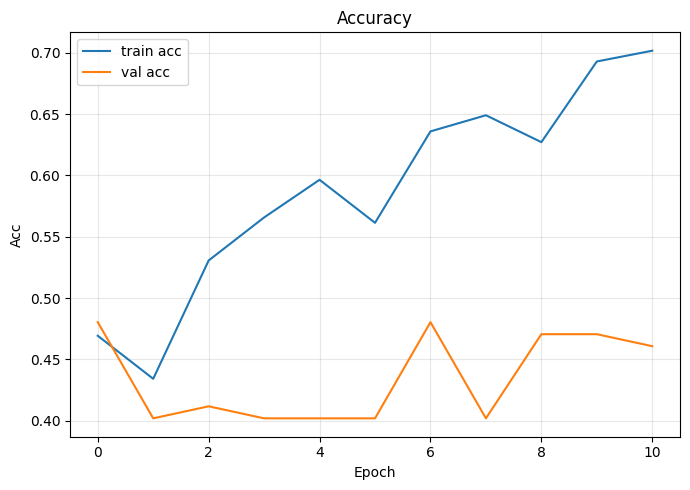

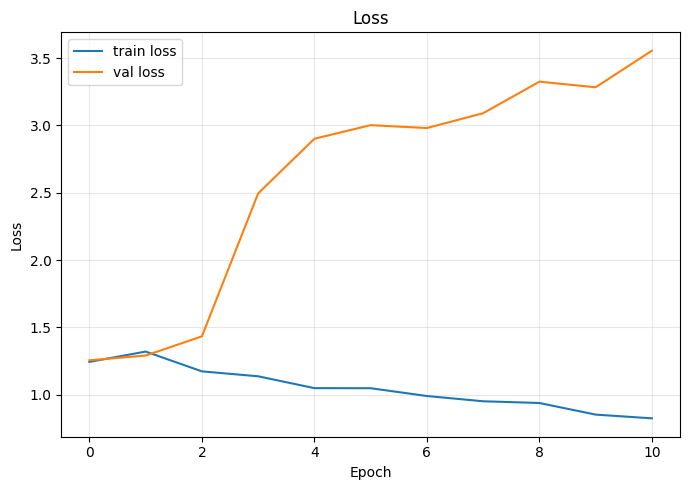

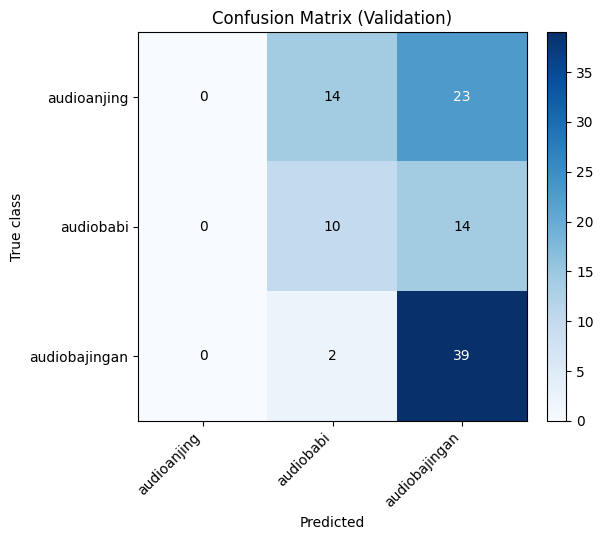

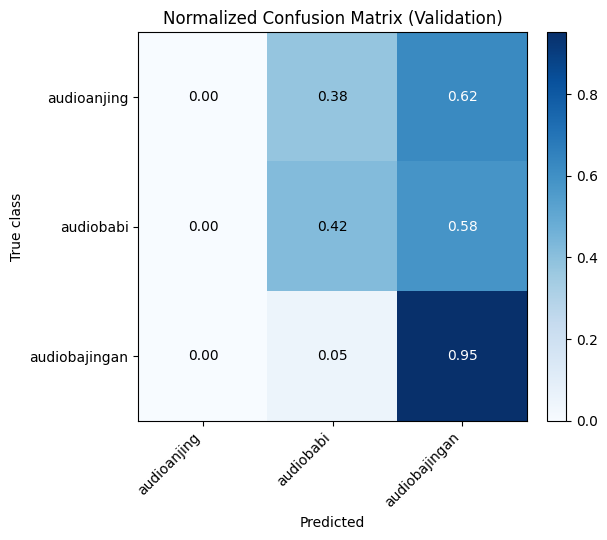

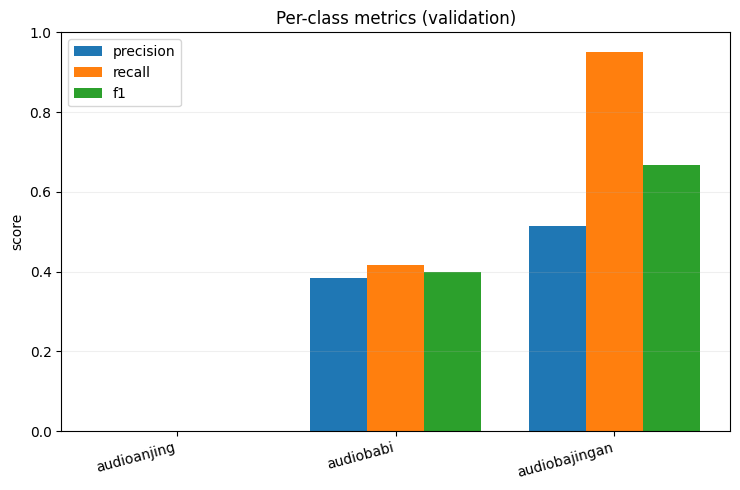

In [10]:
# ============================================================
# Audio CNN (mel-spectrogram) -- Optimized for small datasets
# - Energy-based cropping (RMS) for informative segments
# - Train-stats normalization (per-mel, per-channel)
# - Stable training (CE, no weights first)
# - Full training + evaluation + plots
# ============================================================
import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
from pathlib import Path
import librosa, matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras import layers, models, regularizers, callbacks, optimizers
import tensorflow as tf

# ------------------- Config -------------------
DATA_DIR   = r"D:\web\cnn_clasification\archive\Data\genres_original"  # ganti sesuai lokasimu
SR         = 22050
WIN_SEC    = 3.0       # durasi segmen (detik) → 2.0–3.0 biasanya mantap
STEP_SEC   = 0.5       # hop saat scan RMS
TOPK_TRAIN = 5         # training: pilih acak dari K segmen RMS tertinggi
BALANCE_TO = 60        # target sampel per kelas pada TRAIN (via cropping)
N_MELS     = 128
N_FFT      = 2048
HOP        = 256       # lebih rapat dari 512 → time-res lebih detail
FMIN, FMAX = 20, 8000
SEED       = 42

LR         = 1e-3      # stabil untuk dataset kecil
EPOCHS     = 80
BATCH_SIZE = 32

np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# ------------------- I/O helpers -------------------
def list_audio_files(root, exts=(".wav",".mp3",".flac",".ogg",".m4a",".WAV",".MP3",".FLAC")):
    root = Path(root)
    return [p for p in sorted(root.rglob("*")) if p.suffix in exts and p.is_file()]

def load_full(path, sr=SR):
    y, sr = librosa.load(path, sr=sr, mono=True)
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))
    # pre-emphasis helps transients
    y = np.append(y[0], y[1:] - 0.97 * y[:-1])
    return y, sr

def scan_rms(y, sr, win_sec=WIN_SEC, step_sec=STEP_SEC):
    win = int(win_sec * sr)
    step = int(step_sec * sr)
    if len(y) < win:
        y = np.pad(y, (0, win - len(y)))
    starts = np.arange(0, len(y) - win + 1, step)
    if starts.size == 0:
        starts = np.array([0])
    rms = np.array([np.sqrt(np.mean(y[s:s+win]**2)) + 1e-8 for s in starts], dtype=np.float32)
    return starts, rms, win

def crop_at(y, start, win):
    end = start + win
    if end > len(y):
        y = np.pad(y, (0, end - len(y)))
    return y[start:start+win]

def mel3_from_wave(y, sr):
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0
    )
    logS = librosa.power_to_db(S, ref=np.max).astype(np.float32)
    d1   = librosa.feature.delta(logS)
    d2   = librosa.feature.delta(logS, order=2)
    return np.stack([logS, d1, d2], axis=-1).astype(np.float32)   # (H, T, 3)

def pad_to(x, max_len):
    H, W, C = x.shape
    if W >= max_len:
        return x[:, :max_len, :]
    out = np.zeros((H, max_len, C), dtype=np.float32)
    out[:, :W, :] = x
    return out

# ------------------- Dataset builders -------------------
def build_energy_dataset(data_dir, mode="train", balance_to=BALANCE_TO, topk_train=TOPK_TRAIN):
    """mode: 'train' → random among top-K; 'val' → highest-RMS only."""
    root = Path(data_dir)
    class_names = sorted([d.name for d in root.iterdir() if d.is_dir()])
    X_list, y_list, paths = [], [], []

    for ci, cname in enumerate(class_names):
        files = list_audio_files(root / cname)
        target = balance_to if mode == "train" else len(files)
        rep = max(1, int(np.ceil(target / max(1, len(files)))))

        print(f"[{mode.upper()}] {cname}: {len(files)} file → {rep} crop/file")
        for f in files:
            try:
                y_wav, sr = load_full(str(f))
                starts, rms, win = scan_rms(y_wav, sr)
                order = np.argsort(rms)[::-1]  # high → low
                if mode == "train":
                    pick = order[:min(topk_train, len(order))]
                    for _ in range(rep):
                        s = np.random.choice(pick)
                        seg = crop_at(y_wav, starts[s], win)
                        X_list.append(mel3_from_wave(seg, sr)); y_list.append(ci); paths.append(str(f))
                else:
                    s = order[0]  # deterministic
                    seg = crop_at(y_wav, starts[s], win)
                    X_list.append(mel3_from_wave(seg, sr)); y_list.append(ci); paths.append(str(f))
            except Exception as e:
                print("  Gagal:", f, e)

    return X_list, np.array(y_list, np.int64), class_names, np.array(paths)

print("==> Membangun TRAIN...")
X_train_list, y_train, class_names, _ = build_energy_dataset(DATA_DIR, mode="train")
print("==> Membangun VAL...")
X_val_list,   y_val,   _,           _ = build_energy_dataset(DATA_DIR, mode="val")

# Lebar frame → tentukan panjang kanvas (95th percentile dari gabungan train+val)
widths = np.array([x.shape[1] for x in (X_train_list + X_val_list)])
max_len = int(np.percentile(widths, 95))
max_len = max(64, max_len)
print(f"Canvas: HxW = {N_MELS}x{max_len}, Channels=3 | Classes={len(class_names)} {class_names}")

# Pad
X_train_raw = np.stack([pad_to(x, max_len) for x in X_train_list], axis=0)
X_val_raw   = np.stack([pad_to(x, max_len) for x in X_val_list],   axis=0)

# Train-statistics normalization (per-mel, per-channel)
train_mean = X_train_raw.mean(axis=(0, 2))          # (H, C)
train_std  = X_train_raw.std(axis=(0, 2)) + 1e-6    # (H, C)
def apply_train_norm(X): return (X - train_mean[None, :, None, :]) / train_std[None, :, None, :]

X_train = apply_train_norm(X_train_raw)
X_val   = apply_train_norm(X_val_raw)

print("Shapes:", X_train.shape, X_val.shape)

# ------------------- Model -------------------
def build_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)

    # Mulai TANPA SpecAugment untuk baseline; aktifkan setelah pisah kelas mulai terlihat
    x = inp
    # x = SpecAugment(time_mask=0.06, freq_mask=0.06)(inp)

    def block(x, f, drop):
        x = layers.Conv2D(f, 3, padding="same", kernel_regularizer=regularizers.l2(2e-4))(x)
        x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
        x = layers.Conv2D(f, 3, padding="same", kernel_regularizer=regularizers.l2(2e-4))(x)
        x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D((2,2))(x); x = layers.Dropout(drop)(x)
        return x

    x = block(x, 32,  0.25)
    x = block(x, 64,  0.30)
    x = block(x, 128, 0.35)
    x = block(x, 192, 0.40)
    x = layers.Conv2D(256, 3, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Dropout(0.45)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(2e-4))(x)
    x = layers.Dropout(0.45)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out)

num_classes = len(class_names)
model = build_cnn((N_MELS, max_len, 3), num_classes)
model.summary()

# ------------------- Train -------------------
opt = optimizers.Adam(learning_rate=LR)
model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

cbs = [
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint("best_cnn_energy.keras", monitor="val_loss", save_best_only=True, verbose=1),
]

hist = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cbs,
    verbose=1
)

# ------------------- Evaluate -------------------
y_val_prob = model.predict(X_val, verbose=0)
y_val_pred = np.argmax(y_val_prob, axis=1)
print("Val acc:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, target_names=class_names, digits=4))
print("Confusion:\n", confusion_matrix(y_val, y_val_pred))

# ------------------- Plots -------------------
def plot_history(h):
    # Accuracy
    plt.figure(figsize=(7,5))
    plt.plot(h.history['accuracy'], label='train acc')
    plt.plot(h.history['val_accuracy'], label='val acc')
    plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Acc')
    plt.grid(True, alpha=.3); plt.legend(); plt.tight_layout(); plt.show()
    # Loss
    plt.figure(figsize=(7,5))
    plt.plot(h.history['loss'], label='train loss')
    plt.plot(h.history['val_loss'], label='val loss')
    plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.grid(True, alpha=.3); plt.legend(); plt.tight_layout(); plt.show()
plot_history(hist)

def plot_cm(cm, class_names, normalize=False, title="Confusion Matrix"):
    if normalize:
        cm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
        fmt = ".2f"
    else:
        fmt = "d"
    plt.figure(figsize=(6.5,5.5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title); plt.colorbar(fraction=0.046, pad=0.04)
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True class"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()

cm = confusion_matrix(y_val, y_val_pred, labels=np.arange(num_classes))
plot_cm(cm, class_names, normalize=False, title="Confusion Matrix (Validation)")
plot_cm(cm, class_names, normalize=True,  title="Normalized Confusion Matrix (Validation)")

# Bar chart precision/recall/F1
from sklearn.metrics import classification_report
rep = classification_report(y_val, y_val_pred, target_names=class_names, output_dict=True)
prec = [rep[c]['precision'] for c in class_names]
rec  = [rep[c]['recall']    for c in class_names]
f1   = [rep[c]['f1-score']  for c in class_names]
x = np.arange(len(class_names)); w = 0.26
plt.figure(figsize=(7.5,5))
plt.bar(x - w, prec, width=w, label='precision')
plt.bar(x,      rec,  width=w, label='recall')
plt.bar(x + w,  f1,   width=w, label='f1')
plt.xticks(x, class_names, rotation=15, ha='right')
plt.ylim(0,1); plt.ylabel('score'); plt.title('Per-class metrics (validation)')
plt.grid(True, axis='y', alpha=.2); plt.legend(); plt.tight_layout(); plt.show()


==> Membangun TRAIN (boost kelas lemah)...
[TRAIN] audioanjing: 23 file → 6 crop/file (target≈120)
[TRAIN] audiobabi: 24 file → 5 crop/file (target≈120)
[TRAIN] audiobajingan: 24 file → 3 crop/file (target≈60)
==> Membangun VAL...
[VAL] audioanjing: 23 file → 1 crop/file (target≈23)
[VAL] audiobabi: 24 file → 1 crop/file (target≈24)
[VAL] audiobajingan: 24 file → 1 crop/file (target≈24)
Canvas: HxW = 128x259, Channels=3 | Classes=3 ['audioanjing', 'audiobabi', 'audiobajingan']
Shapes: (330, 128, 259, 3) (71, 128, 259, 3)


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)           │ (None, 128, 259, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spec_augment_7 (SpecAugment)         │ (None, 128, 259, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_81 (Conv2D)                   │ (None, 128, 259, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_81               │ (None, 128, 259, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_81 (Activation)           │ (None, 128, 259, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_82 (Conv2D)                   │ (None, 128, 259, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_82               │ (None, 128, 259, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_82 (Activation)           │ (None, 128, 259, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_36 (MaxPooling2D)      │ (None, 64, 129, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_54 (Dropout)                 │ (None, 64, 129, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_83 (Conv2D)                   │ (None, 64, 129, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_83               │ (None, 64, 129, 64)         │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_83 (Activation)           │ (None, 64, 129, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_84 (Conv2D)                   │ (None, 64, 129, 64)         │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_84               │ (None, 64, 129, 64)         │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_84 (Activation)           │ (None, 64, 129, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_37 (MaxPooling2D)      │ (None, 32, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_55 (Dropout)                 │ (None, 32, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_85 (Conv2D)                   │ (None, 32, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,353,891 (5.16 MB)

 Trainable params: 1,351,715 (5.16 MB)

 Non-trainable params: 2,176 (8.50 KB)

Epoch 1/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4028 - loss: 1.2820
Epoch 1: val_loss improved from None to 1.22557, saving model to best_cnn_energy.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.4061 - loss: 1.2903 - val_accuracy: 0.4225 - val_loss: 1.2256 - learning_rate: 0.0010
Epoch 2/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4840 - loss: 1.2778
Epoch 2: val_loss improved from 1.22557 to 1.21069, saving model to best_cnn_energy.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5000 - loss: 1.2367 - val_accuracy: 0.4507 - val_loss: 1.2107 - learning_rate: 0.0010
Epoch 3/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5299 - loss: 1.1570
Epoch 3: val_loss improved from 1.21069 to 1.20014, saving model to best_cnn_energy.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.5485 - loss: 1.1496 - val_accuracy: 0.4789 - val_loss: 1.2001 - learning_rate: 0.0010
Epoch 4/80
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5496

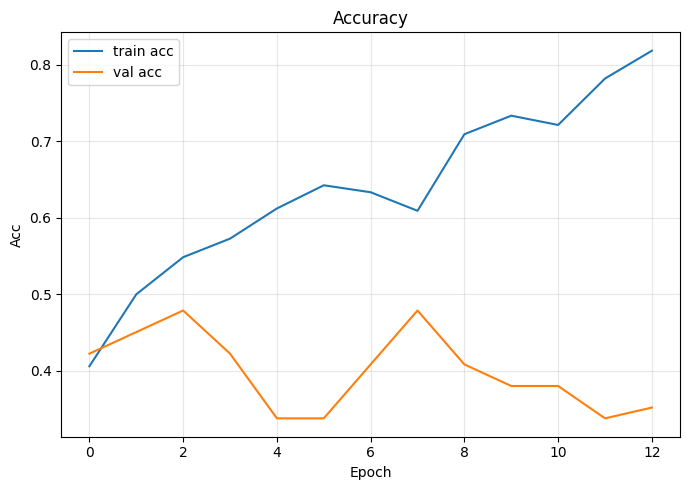

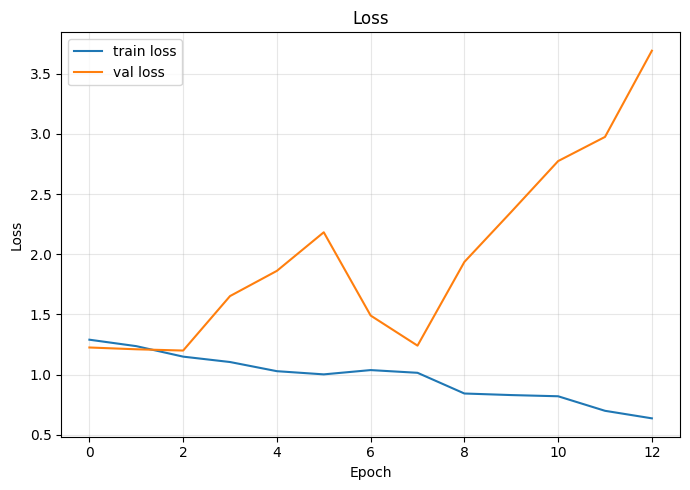

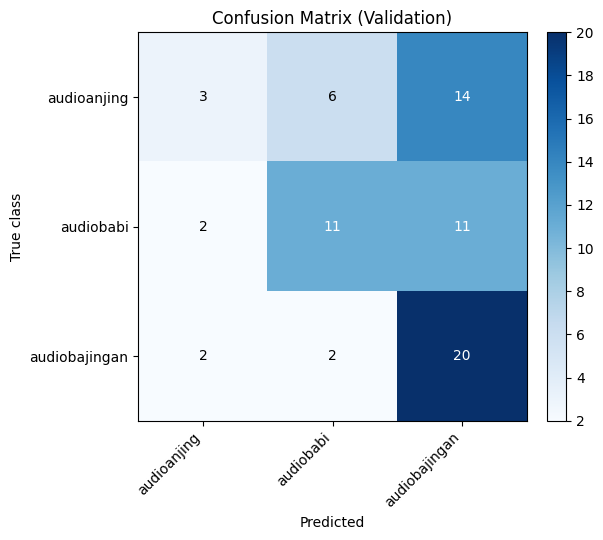

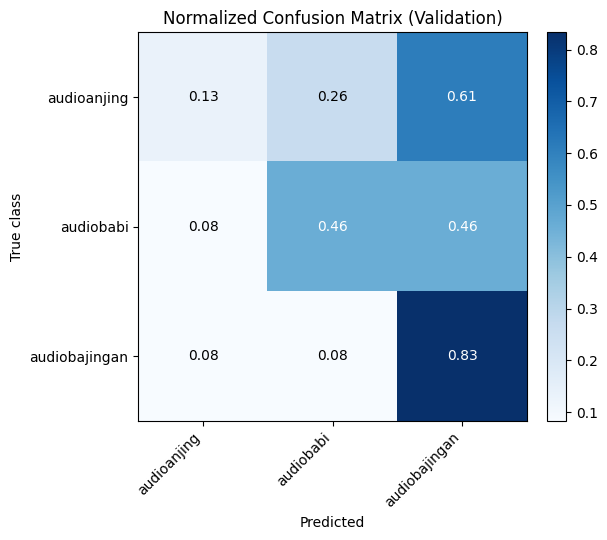

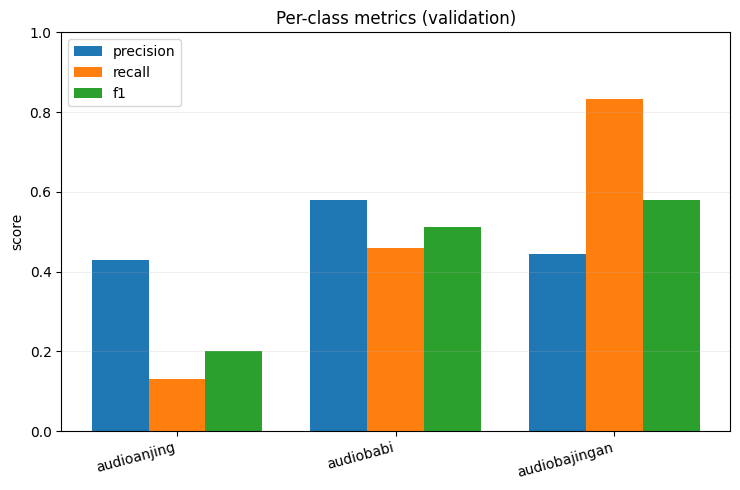

In [14]:
# ============================================================
# Audio CNN (mel-spectrogram) — Small-Data Optimized Pipeline
# ============================================================
import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
from pathlib import Path
import librosa, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks, optimizers

# ------------------- Config -------------------
DATA_DIR   = r"D:\web\cnn_clasification\archive\Data\genres_original"  # ganti sesuai foldermu
SR         = 22050
WIN_SEC    = 3.0         # durasi segmen (detik)
STEP_SEC   = 0.5         # hop saat scan RMS
TOPK_TRAIN = 5           # TRAIN: ambil acak dari top-K segmen RMS tertinggi per file
# target sampel per kelas di TRAIN (over-sample kelas lemah)
BALANCE_TO_PER_CLASS = {
    "audioanjing":   120,
    "audiobabi":     120,
    "audiobajingan":  60,
}

N_MELS     = 128
N_FFT      = 2048
HOP        = 256         # lebih rapat dari 512 → detail temporal lebih baik
FMIN, FMAX = 20, 8000

SEED       = 42
LR         = 1e-3
EPOCHS     = 80
BATCH_SIZE = 32

np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# ------------------- Utils I/O & DSP -------------------
def list_audio_files(root, exts=(".wav",".mp3",".flac",".ogg",".m4a",".WAV",".MP3",".FLAC")):
    root = Path(root)
    return [p for p in sorted(root.rglob("*")) if p.suffix in exts and p.is_file()]

def load_full(path, sr=SR):
    y, sr = librosa.load(path, sr=sr, mono=True)
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))
    # pre-emphasis (membantu konsonan/transien)
    y = np.append(y[0], y[1:] - 0.97 * y[:-1])
    return y, sr

def scan_rms(y, sr, win_sec=WIN_SEC, step_sec=STEP_SEC):
    win  = int(win_sec * sr)
    step = int(step_sec * sr)
    if len(y) < win:
        y = np.pad(y, (0, win - len(y)))
    starts = np.arange(0, len(y) - win + 1, step)
    if starts.size == 0: starts = np.array([0])
    rms = np.array([np.sqrt(np.mean(y[s:s+win]**2)) + 1e-8 for s in starts], dtype=np.float32)
    return starts, rms, win

def crop_at(y, start, win):
    end = start + win
    if end > len(y): y = np.pad(y, (0, end - len(y)))
    return y[start:end]

def mel3_from_wave(y, sr):
    # ---- NEW: per-segment loudness (RMS) normalization ----
    seg_rms = np.sqrt(np.mean(y**2)) + 1e-8
    y = y / seg_rms

    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0
    )                                   # (n_mels, T)
    logS = librosa.power_to_db(S, ref=np.max).astype(np.float32)
    d1   = librosa.feature.delta(logS)
    d2   = librosa.feature.delta(logS, order=2)
    return np.stack([logS, d1, d2], axis=-1).astype(np.float32)  # (H, T, 3)

def pad_to(x, max_len):
    H, W, C = x.shape
    if W >= max_len: return x[:, :max_len, :]
    out = np.zeros((H, max_len, C), dtype=np.float32)
    out[:, :W, :] = x
    return out

# ------------------- SpecAugment (Keras 3-safe) -------------------
class SpecAugment(layers.Layer):
    """Masking 1 band waktu + 1 band frekuensi per-sample."""
    def __init__(self, time_mask=0.06, freq_mask=0.06, **kwargs):
        super().__init__(**kwargs)
        self.time_mask = float(time_mask)
        self.freq_mask = float(freq_mask)
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"time_mask": self.time_mask, "freq_mask": self.freq_mask})
        return cfg
    def compute_output_shape(self, input_shape): return input_shape
    def _mask_one(self, sample):
        H = tf.shape(sample)[0]; W = tf.shape(sample)[1]; C = tf.shape(sample)[2]
        t_w = tf.maximum(1, tf.cast(tf.round(self.time_mask * tf.cast(W, tf.float32)), tf.int32))
        f_w = tf.maximum(1, tf.cast(tf.round(self.freq_mask * tf.cast(H, tf.float32)), tf.int32))
        t0 = tf.cond(W > t_w, lambda: tf.random.uniform([], 0, W - t_w + 1, dtype=tf.int32), lambda: 0)
        f0 = tf.cond(H > f_w, lambda: tf.random.uniform([], 0, H - f_w + 1, dtype=tf.int32), lambda: 0)
        cols = tf.range(W)[tf.newaxis, :, tf.newaxis]
        rows = tf.range(H)[:, tf.newaxis, tf.newaxis]
        time_band = tf.logical_and(cols >= t0, cols < t0 + t_w)
        freq_band = tf.logical_and(rows >= f0, rows < f0 + f_w)
        time_mask = tf.cast(tf.logical_not(time_band), sample.dtype); time_mask = tf.tile(time_mask, [H, 1, C])
        freq_mask = tf.cast(tf.logical_not(freq_band), sample.dtype); freq_mask = tf.tile(freq_mask, [1, W, C])
        return sample * (time_mask * freq_mask)
    def call(self, x, training=False):
        if not training or (self.time_mask <= 0 and self.freq_mask <= 0): return x
        return tf.map_fn(self._mask_one, x)

# ------------------- Dataset builders -------------------
def build_energy_dataset(data_dir, mode="train", balance_to_per_class=None, topk_train=TOPK_TRAIN):
    """
    mode='train': pilih acak dari top-K RMS segmen; gunakan target per-kelas (over/under-sample).
    mode='val'  : 1 segmen RMS tertinggi per file (deterministik).
    """
    root = Path(data_dir)
    class_names = sorted([d.name for d in root.iterdir() if d.is_dir()])
    X_list, y_list, paths = [], [], []

    for ci, cname in enumerate(class_names):
        files = list_audio_files(root / cname)

        if mode == "train" and balance_to_per_class is not None:
            target = balance_to_per_class.get(cname, len(files))
        else:
            target = len(files)

        rep = max(1, int(np.ceil(target / max(1, len(files)))))
        print(f"[{mode.upper()}] {cname}: {len(files)} file → {rep} crop/file (target≈{target})")

        for f in files:
            try:
                y_wav, sr = load_full(str(f))
                starts, rms, win = scan_rms(y_wav, sr)
                order = np.argsort(rms)[::-1]  # high → low

                if mode == "train":
                    pick = order[:min(topk_train, len(order))]
                    for _ in range(rep):
                        s = np.random.choice(pick)
                        seg = crop_at(y_wav, starts[s], win)
                        X_list.append(mel3_from_wave(seg, sr)); y_list.append(ci); paths.append(str(f))
                else:
                    s = order[0]
                    seg = crop_at(y_wav, starts[s], win)
                    X_list.append(mel3_from_wave(seg, sr)); y_list.append(ci); paths.append(str(f))
            except Exception as e:
                print("  Gagal:", f, e)

    return X_list, np.array(y_list, np.int64), class_names, np.array(paths)

# -------- Build datasets --------
print("==> Membangun TRAIN (boost kelas lemah)...")
X_train_list, y_train, class_names, _ = build_energy_dataset(
    DATA_DIR, mode="train", balance_to_per_class=BALANCE_TO_PER_CLASS
)
print("==> Membangun VAL...")
X_val_list,   y_val,   _,           _ = build_energy_dataset(DATA_DIR, mode="val")

# Tentukan panjang kanvas (95th percentile)
widths = np.array([x.shape[1] for x in (X_train_list + X_val_list)])
max_len = int(np.percentile(widths, 95)); max_len = max(64, max_len)
print(f"Canvas: HxW = {N_MELS}x{max_len}, Channels=3 | Classes={len(class_names)} {class_names}")

# Padkan
X_train_raw = np.stack([pad_to(x, max_len) for x in X_train_list], axis=0)
X_val_raw   = np.stack([pad_to(x, max_len) for x in X_val_list],   axis=0)

# Normalisasi pakai statistik TRAIN (per-mel, per-channel)
train_mean = X_train_raw.mean(axis=(0, 2))          # (H, C)
train_std  = X_train_raw.std(axis=(0, 2)) + 1e-6    # (H, C)
def apply_train_norm(X): return (X - train_mean[None, :, None, :]) / train_std[None, :, None, :]

X_train = apply_train_norm(X_train_raw)
X_val   = apply_train_norm(X_val_raw)
print("Shapes:", X_train.shape, X_val.shape)

# ------------------- Model -------------------
def build_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    # SpecAugment ringan (boleh matikan dulu kalau mau baseline)
    x = SpecAugment(time_mask=0.06, freq_mask=0.06)(inp)

    def block(x, f, drop):
        x = layers.Conv2D(f, 3, padding="same", kernel_regularizer=regularizers.l2(2e-4))(x)
        x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
        x = layers.Conv2D(f, 3, padding="same", kernel_regularizer=regularizers.l2(2e-4))(x)
        x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D((2,2))(x); x = layers.Dropout(drop)(x)
        return x

    x = block(x, 32,  0.25)
    x = block(x, 64,  0.30)
    x = block(x, 128, 0.35)
    x = block(x, 192, 0.40)

    x = layers.Conv2D(256, 3, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Dropout(0.45)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(2e-4))(x)
    x = layers.Dropout(0.45)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out)

num_classes = len(class_names)
model = build_cnn((N_MELS, max_len, 3), num_classes)
model.summary()

# ------------------- Training -------------------
opt = optimizers.Adam(learning_rate=LR)
model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

cbs = [
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint("best_cnn_energy.keras", monitor="val_loss", save_best_only=True, verbose=1),
]

hist = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cbs,
    verbose=1
)

# ------------------- Evaluate -------------------
y_val_prob = model.predict(X_val, verbose=0)
y_val_pred = np.argmax(y_val_prob, axis=1)
print("Val acc:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, target_names=class_names, digits=4))
print("Confusion:\n", confusion_matrix(y_val, y_val_pred))

# ------------------- Plots -------------------
def plot_history(h):
    plt.figure(figsize=(7,5))
    plt.plot(h.history['accuracy'], label='train acc')
    plt.plot(h.history['val_accuracy'], label='val acc')
    plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Acc')
    plt.grid(True, alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(h.history['loss'], label='train loss')
    plt.plot(h.history['val_loss'], label='val loss')
    plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.grid(True, alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

plot_history(hist)

def plot_cm(cm, class_names, normalize=False, title="Confusion Matrix"):
    if normalize:
        cm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9); fmt=".2f"
    else:
        fmt="d"
    plt.figure(figsize=(6.5,5.5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title); plt.colorbar(fraction=0.046, pad=0.04)
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right"); plt.yticks(ticks, class_names)
    thresh = cm.max()/2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True class"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()

cm = confusion_matrix(y_val, y_val_pred, labels=np.arange(num_classes))
plot_cm(cm, class_names, normalize=False, title="Confusion Matrix (Validation)")
plot_cm(cm, class_names, normalize=True,  title="Normalized Confusion Matrix (Validation)")

# Per-class precision/recall/F1
rep = classification_report(y_val, y_val_pred, target_names=class_names, output_dict=True)
prec = [rep[c]['precision'] for c in class_names]
rec  = [rep[c]['recall']    for c in class_names]
f1   = [rep[c]['f1-score']  for c in class_names]
x = np.arange(len(class_names)); w = 0.26
plt.figure(figsize=(7.5,5))
plt.bar(x - w, prec, width=w, label='precision')
plt.bar(x,      rec,  width=w, label='recall')
plt.bar(x + w,  f1,   width=w, label='f1')
plt.xticks(x, class_names, rotation=15, ha='right'); plt.ylim(0,1)
plt.ylabel('score'); plt.title('Per-class metrics (validation)')
plt.grid(True, axis='y', alpha=.2); plt.legend(); plt.tight_layout(); plt.show()

# ------------------- Tips lanjutan -------------------
# - Jika kelas tertentu masih lemah, naikkan targetnya di BALANCE_TO_PER_CLASS (mis. 160–200).
# - Jika baseline sudah stabil, boleh naikkan SpecAugment ke (0.1, 0.1).
# - Ingin lompatan besar di data kecil? Pakai transfer learning (YAMNet/PANN). 


==> Membangun TRAIN (equalized via augment)...
[TRAIN] audioanjing: 23 file → 6 crop/file (target≈120)
[TRAIN] audiobabi: 24 file → 5 crop/file (target≈120)
[TRAIN] audiobajingan: 24 file → 5 crop/file (target≈120)
==> Membangun VAL...
[VAL] audioanjing: 23 file → 1 crop/file (target≈23)
[VAL] audiobabi: 24 file → 1 crop/file (target≈24)
[VAL] audiobajingan: 24 file → 1 crop/file (target≈24)
Canvas: HxW = 128x259, Channels=3 | Classes=3 ['audioanjing', 'audiobabi', 'audiobajingan']
Shapes: (378, 128, 259, 3) (71, 128, 259, 3)


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)          │ (None, 128, 259, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spec_augment_11 (SpecAugment)        │ (None, 128, 259, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_117 (Conv2D)                  │ (None, 128, 259, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_117              │ (None, 128, 259, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_117 (Activation)          │ (None, 128, 259, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_118 (Conv2D)                  │ (None, 128, 259, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_118              │ (None, 128, 259, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_118 (Activation)          │ (None, 128, 259, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_52 (MaxPooling2D)      │ (None, 64, 129, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_78 (Dropout)                 │ (None, 64, 129, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_119 (Conv2D)                  │ (None, 64, 129, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_119              │ (None, 64, 129, 64)         │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_119 (Activation)          │ (None, 64, 129, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_120 (Conv2D)                  │ (None, 64, 129, 64)         │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_120              │ (None, 64, 129, 64)         │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_120 (Activation)          │ (None, 64, 129, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_53 (MaxPooling2D)      │ (None, 32, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_79 (Dropout)                 │ (None, 32, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_121 (Conv2D)                  │ (None, 32, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,353,891 (5.16 MB)

 Trainable params: 1,351,715 (5.16 MB)

 Non-trainable params: 2,176 (8.50 KB)

Epoch 1/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4112 - loss: 1.3623
Epoch 1: val_loss improved from None to 1.23576, saving model to best_cnn_equalized.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.4312 - loss: 1.3152 - val_accuracy: 0.4366 - val_loss: 1.2358 - learning_rate: 0.0010
Epoch 2/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4156 - loss: 1.2943
Epoch 2: val_loss improved from 1.23576 to 1.18505, saving model to best_cnn_equalized.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.4153 - loss: 1.2957 - val_accuracy: 0.4789 - val_loss: 1.1850 - learning_rate: 0.0010
Epoch 3/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4826 - loss: 1.2595
Epoch 3: val_loss did not improve from 1.18505
12/12 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.5000 - loss: 1.2270 - val_accuracy: 0.3521 - val_loss: 1.4286 - learning_rate: 0.0010
Epoch 4/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5235 - loss: 1.1464
Epoch 4: val_loss did

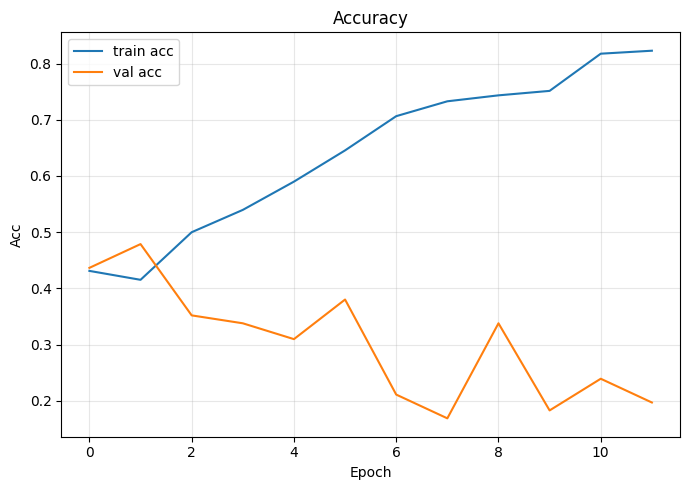

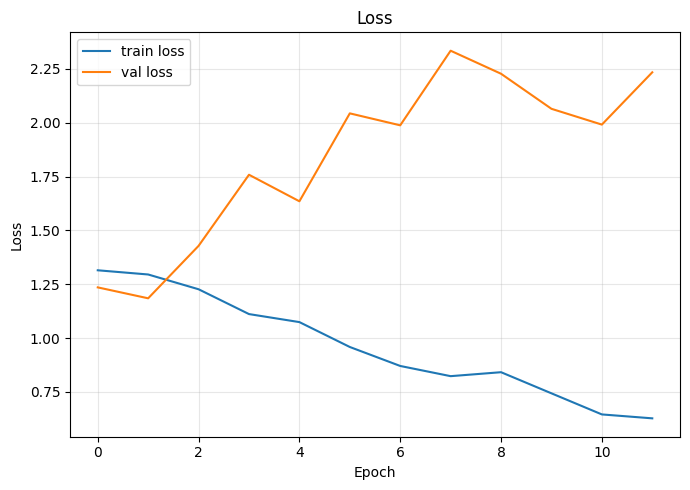

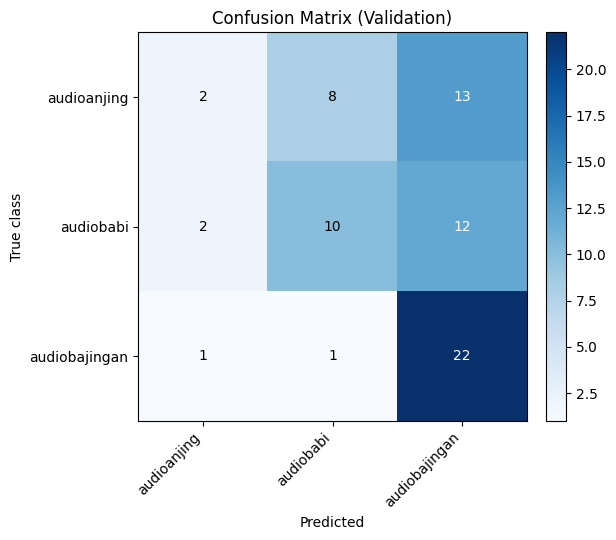

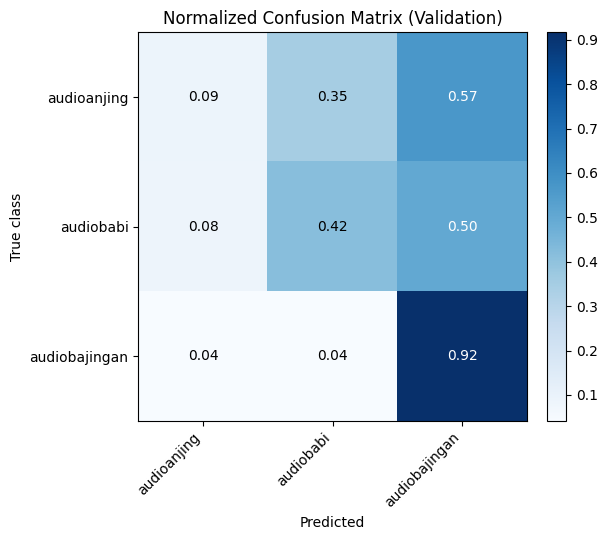

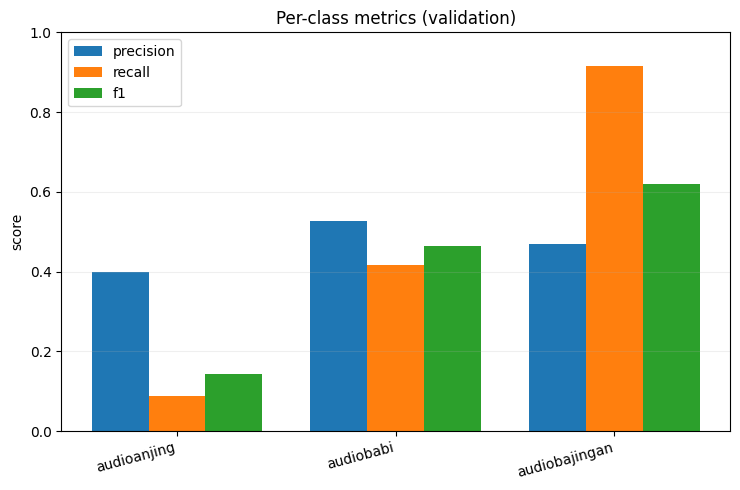

In [18]:
# ============================================================
# Audio CNN (mel-spectrogram) — Equalized per-class via Augment
# - Pakai semua file; jumlah sampel TRAIN per kelas disamakan (120)
# - Energy-based cropping (RMS): TRAIN=acak dari top-K, VAL=top-1
# - Per-segment RMS normalization + train-stats normalization
# - SpecAugment ringan, CE loss standar
# ============================================================
import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
from pathlib import Path
import librosa, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks, optimizers

# ------------------- Config -------------------
DATA_DIR   = r"D:\web\cnn_clasification\archive\Data\genres_original"  # ganti ke foldermu
SR         = 22050
WIN_SEC    = 3.0         # durasi segmen (detik) → 2.0–3.0 umum dipakai
STEP_SEC   = 0.5         # hop saat scan RMS
TOPK_TRAIN = 5           # TRAIN: sampling acak dari K segmen RMS tertinggi per file
# Samakan jumlah contoh per kelas (TRAIN) ke 120 via augment (tanpa buang file)
BALANCE_TO_PER_CLASS = {
    "audioanjing":   120,
    "audiobabi":     120,
    "audiobajingan": 120,
}

N_MELS     = 128
N_FFT      = 2048
HOP        = 256         # lebih rapat dari 512 → time-res lebih baik
FMIN, FMAX = 20, 8000

SEED       = 42
LR         = 1e-3
EPOCHS     = 80
BATCH_SIZE = 32

np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# ------------------- Utils I/O & DSP -------------------
def list_audio_files(root, exts=(".wav",".mp3",".flac",".ogg",".m4a",".WAV",".MP3",".FLAC")):
    root = Path(root)
    return [p for p in sorted(root.rglob("*")) if p.suffix in exts and p.is_file()]

def load_full(path, sr=SR):
    y, sr = librosa.load(path, sr=sr, mono=True)
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))
    # pre-emphasis (membantu transien/konsonan)
    y = np.append(y[0], y[1:] - 0.97 * y[:-1])
    return y, sr

def scan_rms(y, sr, win_sec=WIN_SEC, step_sec=STEP_SEC):
    win  = int(win_sec * sr)
    step = int(step_sec * sr)
    if len(y) < win:
        y = np.pad(y, (0, win - len(y)))
    starts = np.arange(0, len(y) - win + 1, step)
    if starts.size == 0:
        starts = np.array([0])
    # RMS per kandidat segmen
    rms = np.array([np.sqrt(np.mean(y[s:s+win]**2)) + 1e-8 for s in starts], dtype=np.float32)
    return starts, rms, win

def crop_at(y, start, win):
    end = start + win
    if end > len(y):
        y = np.pad(y, (0, end - len(y)))
    return y[start:end]

def mel3_from_wave(y, sr):
    # ---- per-segment loudness normalization (hilangkan bias 'kelas paling keras') ----
    seg_rms = np.sqrt(np.mean(y**2)) + 1e-8
    y = y / seg_rms

    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0
    )                                   # (n_mels, T)
    logS = librosa.power_to_db(S, ref=np.max).astype(np.float32)
    d1   = librosa.feature.delta(logS)
    d2   = librosa.feature.delta(logS, order=2)
    return np.stack([logS, d1, d2], axis=-1).astype(np.float32)  # (H, T, 3)

def pad_to(x, max_len):
    H, W, C = x.shape
    if W >= max_len:
        return x[:, :max_len, :]
    out = np.zeros((H, max_len, C), dtype=np.float32)
    out[:, :W, :] = x
    return out

# ------------------- SpecAugment (Keras 3-safe) -------------------
class SpecAugment(layers.Layer):
    """Masking 1 band waktu + 1 band frekuensi per-sample."""
    def __init__(self, time_mask=0.06, freq_mask=0.06, **kwargs):
        super().__init__(**kwargs)
        self.time_mask = float(time_mask)
        self.freq_mask = float(freq_mask)
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"time_mask": self.time_mask, "freq_mask": self.freq_mask})
        return cfg
    def compute_output_shape(self, input_shape): return input_shape
    def _mask_one(self, sample):
        H = tf.shape(sample)[0]; W = tf.shape(sample)[1]; C = tf.shape(sample)[2]
        t_w = tf.maximum(1, tf.cast(tf.round(self.time_mask * tf.cast(W, tf.float32)), tf.int32))
        f_w = tf.maximum(1, tf.cast(tf.round(self.freq_mask * tf.cast(H, tf.float32)), tf.int32))
        t0 = tf.cond(W > t_w, lambda: tf.random.uniform([], 0, W - t_w + 1, dtype=tf.int32), lambda: 0)
        f0 = tf.cond(H > f_w, lambda: tf.random.uniform([], 0, H - f_w + 1, dtype=tf.int32), lambda: 0)
        cols = tf.range(W)[tf.newaxis, :, tf.newaxis]
        rows = tf.range(H)[:, tf.newaxis, tf.newaxis]
        time_band = tf.logical_and(cols >= t0, cols < t0 + t_w)
        freq_band = tf.logical_and(rows >= f0, rows < f0 + f_w)
        time_mask = tf.cast(tf.logical_not(time_band), sample.dtype); time_mask = tf.tile(time_mask, [H, 1, C])
        freq_mask = tf.cast(tf.logical_not(freq_band), sample.dtype); freq_mask = tf.tile(freq_mask, [1, W, C])
        return sample * (time_mask * freq_mask)
    def call(self, x, training=False):
        if not training or (self.time_mask <= 0 and self.freq_mask <= 0): return x
        return tf.map_fn(self._mask_one, x)

# ------------------- Dataset builders -------------------
def build_energy_dataset(data_dir, mode="train", balance_to_per_class=None, topk_train=TOPK_TRAIN):
    """
    mode='train': augment sampai target per kelas (pakai semua file; sampling dari top-K RMS segmen).
    mode='val'  : 1 segmen RMS tertinggi per file (deterministik).
    """
    root = Path(data_dir)
    class_names = sorted([d.name for d in root.iterdir() if d.is_dir()])
    X_list, y_list, paths = [], [], []

    for ci, cname in enumerate(class_names):
        files = list_audio_files(root / cname)

        # Tentukan target per kelas (TRAIN) → samakan ke 120; VAL tetap jumlah file
        if mode == "train" and balance_to_per_class is not None:
            target = balance_to_per_class.get(cname, len(files))
        else:
            target = len(files)

        rep = max(1, int(np.ceil(target / max(1, len(files)))))
        print(f"[{mode.upper()}] {cname}: {len(files)} file → {rep} crop/file (target≈{target})")

        for f in files:
            try:
                y_wav, sr = load_full(str(f))
                starts, rms, win = scan_rms(y_wav, sr)
                order = np.argsort(rms)[::-1]  # high → low

                if mode == "train":
                    pick = order[:min(topk_train, len(order))]  # kandidat segmen terbaik
                    for _ in range(rep):
                        s = np.random.choice(pick)
                        seg = crop_at(y_wav, starts[s], win)
                        X_list.append(mel3_from_wave(seg, sr)); y_list.append(ci); paths.append(str(f))
                else:
                    s = order[0]  # segmen terbaik tunggal (deterministik)
                    seg = crop_at(y_wav, starts[s], win)
                    X_list.append(mel3_from_wave(seg, sr)); y_list.append(ci); paths.append(str(f))
            except Exception as e:
                print("  Gagal:", f, e)

    return X_list, np.array(y_list, np.int64), class_names, np.array(paths)

# -------- Build datasets --------
print("==> Membangun TRAIN (equalized via augment)...")
X_train_list, y_train, class_names, _ = build_energy_dataset(
    DATA_DIR, mode="train", balance_to_per_class=BALANCE_TO_PER_CLASS
)
print("==> Membangun VAL...")
X_val_list,   y_val,   _,           _ = build_energy_dataset(DATA_DIR, mode="val")

# Tentukan panjang kanvas (95th percentile gabungan)
widths = np.array([x.shape[1] for x in (X_train_list + X_val_list)])
max_len = int(np.percentile(widths, 95)); max_len = max(64, max_len)
print(f"Canvas: HxW = {N_MELS}x{max_len}, Channels=3 | Classes={len(class_names)} {class_names}")

# Padkan
X_train_raw = np.stack([pad_to(x, max_len) for x in X_train_list], axis=0)
X_val_raw   = np.stack([pad_to(x, max_len) for x in X_val_list],   axis=0)

# Normalisasi pakai statistik TRAIN (per-mel, per-channel)
train_mean = X_train_raw.mean(axis=(0, 2))          # (H, C)
train_std  = X_train_raw.std(axis=(0, 2)) + 1e-6    # (H, C)
def apply_train_norm(X): return (X - train_mean[None, :, None, :]) / train_std[None, :, None, :]

X_train = apply_train_norm(X_train_raw)
X_val   = apply_train_norm(X_val_raw)
print("Shapes:", X_train.shape, X_val.shape)

# ------------------- Model -------------------
def build_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    # SpecAugment ringan (bisa matikan sementara untuk baseline)
    x = SpecAugment(time_mask=0.06, freq_mask=0.06)(inp)

    def block(x, f, drop):
        x = layers.Conv2D(f, 3, padding="same", kernel_regularizer=regularizers.l2(2e-4))(x)
        x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
        x = layers.Conv2D(f, 3, padding="same", kernel_regularizer=regularizers.l2(2e-4))(x)
        x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D((2,2))(x); x = layers.Dropout(drop)(x)
        return x

    x = block(x, 32,  0.25)
    x = block(x, 64,  0.30)
    x = block(x, 128, 0.35)
    x = block(x, 192, 0.40)

    x = layers.Conv2D(256, 3, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Dropout(0.45)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(2e-4))(x)
    x = layers.Dropout(0.45)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out)

num_classes = len(class_names)
model = build_cnn((N_MELS, max_len, 3), num_classes)
model.summary()

# ------------------- Training -------------------
opt = optimizers.Adam(learning_rate=LR)
model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

cbs = [
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint("best_cnn_equalized.keras", monitor="val_loss", save_best_only=True, verbose=1),
]

hist = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cbs,
    verbose=1
)

# ------------------- Evaluate -------------------
y_val_prob = model.predict(X_val, verbose=0)
y_val_pred = np.argmax(y_val_prob, axis=1)
print("Val acc:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, target_names=class_names, digits=4))
print("Confusion:\n", confusion_matrix(y_val, y_val_pred))

# ------------------- Plots -------------------
def plot_history(h):
    plt.figure(figsize=(7,5))
    plt.plot(h.history['accuracy'], label='train acc')
    plt.plot(h.history['val_accuracy'], label='val acc')
    plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Acc')
    plt.grid(True, alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(h.history['loss'], label='train loss')
    plt.plot(h.history['val_loss'], label='val loss')
    plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.grid(True, alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

plot_history(hist)

def plot_cm(cm, class_names, normalize=False, title="Confusion Matrix"):
    if normalize:
        cm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9); fmt=".2f"
    else:
        fmt="d"
    plt.figure(figsize=(6.5,5.5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title); plt.colorbar(fraction=0.046, pad=0.04)
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right"); plt.yticks(ticks, class_names)
    thresh = cm.max()/2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True class"); plt.xlabel("Predicted"); plt.tight_layout(); plt.show()

cm = confusion_matrix(y_val, y_val_pred, labels=np.arange(num_classes))
plot_cm(cm, class_names, normalize=False, title="Confusion Matrix (Validation)")
plot_cm(cm, class_names, normalize=True,  title="Normalized Confusion Matrix (Validation)")

# Per-class precision/recall/F1
rep = classification_report(y_val, y_val_pred, target_names=class_names, output_dict=True)
prec = [rep[c]['precision'] for c in class_names]
rec  = [rep[c]['recall']    for c in class_names]
f1   = [rep[c]['f1-score']  for c in class_names]
x = np.arange(len(class_names)); w = 0.26
plt.figure(figsize=(7.5,5))
plt.bar(x - w, prec, width=w, label='precision')
plt.bar(x,      rec,  width=w, label='recall')
plt.bar(x + w,  f1,   width=w, label='f1')
plt.xticks(x, class_names, rotation=15, ha='right'); plt.ylim(0,1)
plt.ylabel('score'); plt.title('Per-class metrics (validation)')
plt.grid(True, axis='y', alpha=.2); plt.legend(); plt.tight_layout(); plt.show()
